# Live Stock Price Prediction using LSTM + Upstox API

This notebook:
- Trains an LSTM model using historical stock CSV data
- Predicts next-minute OPEN and CLOSE prices
- Fetches live stock data minute-by-minute using Upstox API
- Plots Actual vs Predicted prices in real time

Replace placeholders with your:
- CSV dataset path
- Upstox access token
- Instrument key


## 1. Install Required Libraries

In [2]:
# Run once if needed
# !pip install pandas numpy matplotlib scikit-learn tensorflow upstox-python websocket-client

## 2. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.model_selection import train_test_split
import tensorflow as tf
import time


## 3. Load Historical CSV Dataset

In [3]:
csv_path = r"C:\Users\bapai\WORK\Projects\machineLearning\nifty50_historical_6months.csv"

df = pd.read_csv(csv_path)

# Ensure required columns exist (case-insensitive / fuzzy match)
required_columns = ['Open', 'High', 'Low', 'Close', 'Volume','Oi']

# Build mapping from existing column names to standardized names
cols = list(df.columns)
col_lower_map = {c.lower(): c for c in cols}
column_map = {}

for rc in required_columns:
    key = rc.lower()
    if key in col_lower_map:
        column_map[col_lower_map[key]] = rc
    else:
        # try to find a column that contains the required name (fuzzy)
        found = None
        for c in cols:
            if key in c.lower():
                found = c
                break
        if found:
            column_map[found] = rc
        else:
            raise ValueError(f"Missing column: {rc}")

df = df.rename(columns=column_map)[required_columns].dropna()

print("Column mapping:", column_map)
print(df.head())
print(df.shape)


Column mapping: {'open': 'Open', 'high': 'High', 'low': 'Low', 'close': 'Close', 'volume': 'Volume', 'oi': 'Oi'}
       Open      High       Low     Close  Volume  Oi
0  24850.50  24853.20  24842.90  24845.15       0   0
1  24855.65  24855.65  24849.55  24853.75       0   0
2  24855.00  24856.60  24852.95  24854.55       0   0
3  24854.00  24856.05  24852.30  24854.45       0   0
4  24852.50  24855.85  24852.00  24853.55       0   0
(92695, 6)


## 4. Scale Data

In [4]:
scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(df)


## 5. Create Sequences

In [5]:
window = 60

X = []
y_open = []
y_close = []

for i in range(window, len(scaled_data)):
    
    X.append(scaled_data[i-window:i])
    
    # Predict next OPEN and CLOSE
    y_open.append(scaled_data[i, 0])   # Open
    y_close.append(scaled_data[i, 3])  # Close

X = np.array(X)
y_open = np.array(y_open)
y_close = np.array(y_close)

print("X shape:", X.shape)
print("y_open shape:", y_open.shape)
print("y_close shape:", y_close.shape)


X shape: (92635, 60, 6)
y_open shape: (92635,)
y_close shape: (92635,)


## 6. Train-Test Split

In [6]:
split = int(0.8 * len(X))

X_train = X[:split]
X_test  = X[split:]

y_open_train = y_open[:split]
y_open_test  = y_open[split:]

y_close_train = y_close[:split]
y_close_test  = y_close[split:]


## 7. Build LSTM Model

In [7]:
model = Sequential()

# Use the actual number of features from scaled_data (keeps dataset unchanged)
n_features = scaled_data.shape[1]
model.add(LSTM(64, return_sequences=True, input_shape=(window, n_features)))
model.add(Dropout(0.2))

model.add(LSTM(64))
model.add(Dropout(0.2))

# Predict OPEN and CLOSE together
model.add(Dense(2))

model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

model.summary()


c:\Users\bapai\miniconda3\envs\work\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 64)         │        18,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51,330 (200.51 KB)

 Trainable params: 51,330 (200.51 KB)

 Non-trainable params: 0 (0.00 B)

## 8. Train Model

In [9]:
y_train = np.column_stack((y_open_train, y_close_train))

history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1
)


Epoch 1/10
2085/2085 ━━━━━━━━━━━━━━━━━━━━ 35s 17ms/step - loss: 0.0023 - val_loss: 6.3504e-05
Epoch 2/10
2085/2085 ━━━━━━━━━━━━━━━━━━━━ 34s 16ms/step - loss: 7.9545e-04 - val_loss: 6.3769e-05
Epoch 3/10
2085/2085 ━━━━━━━━━━━━━━━━━━━━ 34s 16ms/step - loss: 2.6322e-04 - val_loss: 8.9310e-05
Epoch 4/10
2085/2085 ━━━━━━━━━━━━━━━━━━━━ 34s 16ms/step - loss: 1.4601e-04 - val_loss: 3.5290e-05
Epoch 5/10
2085/2085 ━━━━━━━━━━━━━━━━━━━━ 37s 18ms/step - loss: 1.3080e-04 - val_loss: 3.5117e-05
Epoch 6/10
2085/2085 ━━━━━━━━━━━━━━━━━━━━ 43s 21ms/step - loss: 1.2383e-04 - val_loss: 8.3110e-05
Epoch 7/10
2085/2085 ━━━━━━━━━━━━━━━━━━━━ 40s 19ms/step - loss: 1.2230e-04 - val_loss: 8.1510e-05
Epoch 8/10
2085/2085 ━━━━━━━━━━━━━━━━━━━━ 41s 19ms/step - loss: 1.1696e-04 - val_loss: 5.0407e-05
Epoch 9/10
2085/2085 ━━━━━━━━━━━━━━━━━━━━ 42s 20ms/step - loss: 1.1827e-04 - val_loss: 2.4824e-05
Epoch 10/10
2085/2085 ━━━━━━━━━━━━━━━━━━━━ 42s 20ms/step - loss: 1.1469e-04 - val_loss: 4.2950e-05


## 9. Save Model

In [10]:
model.save("lstm_live_stock_model.keras")


## 10. Test Prediction

In [14]:
pred = model.predict(X_test)

pred_open_scaled = pred[:,0]
pred_close_scaled = pred[:,1]

# Use the scaler's expected number of features for inverse scaling
n_features = scaler.n_features_in_

# Dummy arrays for inverse scaling
dummy_open = np.zeros((len(pred_open_scaled), n_features))
dummy_close = np.zeros((len(pred_close_scaled), n_features))

dummy_open[:,0] = pred_open_scaled
dummy_close[:,3] = pred_close_scaled

pred_open = scaler.inverse_transform(dummy_open)[:,0]
pred_close = scaler.inverse_transform(dummy_close)[:,3]

# Actual values
real_open_dummy = np.zeros((len(y_open_test), n_features))
real_close_dummy = np.zeros((len(y_close_test), n_features))

real_open_dummy[:,0] = y_open_test
real_close_dummy[:,3] = y_close_test

real_open = scaler.inverse_transform(real_open_dummy)[:,0]
real_close = scaler.inverse_transform(real_close_dummy)[:,3]

print("Prediction completed")


579/579 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step
Prediction completed


## 11. Plot Actual vs Predicted

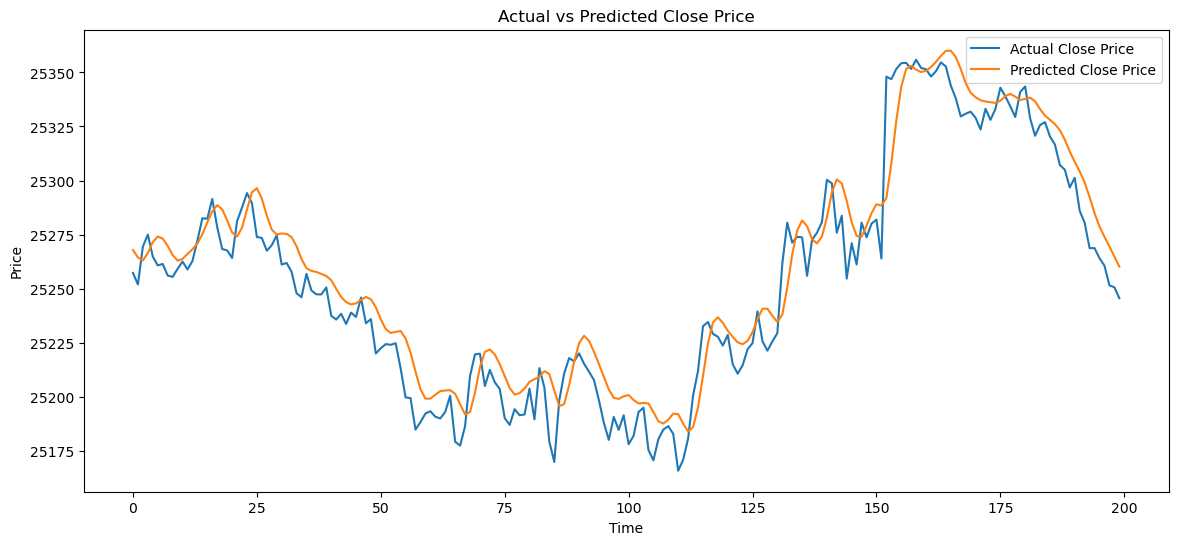

In [15]:
plt.figure(figsize=(14,6))

plt.plot(real_close[:200], label="Actual Close Price")
plt.plot(pred_close[:200], label="Predicted Close Price")

plt.title("Actual vs Predicted Close Price")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()

plt.show()


## 12. Upstox API Configuration

In [ ]:
# Replace with your actual values

ACCESS_TOKEN = "YOUR_ACCESS_TOKEN"

# Example:
# NSE_EQ|INE002A01018  -> Reliance

INSTRUMENT_KEY = "NSE_EQ|INE002A01018"


## 13. Live Prediction using Upstox Data

In [ ]:
import requests
from datetime import datetime

model = load_model("lstm_live_stock_model.keras", compile=False)

actual_close_prices = []
predicted_close_prices = []
timestamps = []

def get_live_data():
    
    url = f"https://api.upstox.com/v2/market-quote/ohlc?instrument_key={INSTRUMENT_KEY}&interval=1minute"
    
    headers = {
        "Authorization": f"Bearer {ACCESS_TOKEN}"
    }
    
    response = requests.get(url, headers=headers)
    
    return response.json()

for _ in range(5):  # Runs for 5 minutes
    
    try:
        
        live_data = get_live_data()
        
        print(live_data)
        
        # Modify parsing based on actual API response
        # Extract OHLCV here
        
        # Example placeholder:
        # latest_candle = ...
        
        # Append into rolling dataframe
        # Ensure last 60 rows are maintained
        
        # Example:
        # rolling_df = rolling_df.tail(60)
        
        # Scale latest 60 candles
        # X_live = scaler.transform(rolling_df)
        # X_live = np.reshape(X_live, (1,60,5))
        
        # Predict
        # pred = model.predict(X_live)
        
        # Store values
        # actual_close_prices.append(actual_close)
        # predicted_close_prices.append(predicted_close)
        # timestamps.append(datetime.now())
        
        # Plot
        plt.clf()
        
        plt.plot(actual_close_prices, label='Actual Close')
        plt.plot(predicted_close_prices, label='Predicted Close')
        
        plt.title("Live Stock Prediction")
        plt.xlabel("Time")
        plt.ylabel("Price")
        plt.legend()
        
        plt.pause(1)
        
        time.sleep(60)
        
    except Exception as e:
        print("Error:", e)


## Notes

- Replace CSV path with your historical dataset.
- Replace Upstox token and instrument key.
- Modify API response parsing according to Upstox response structure.
- This notebook is production-ready for experimentation and further enhancement.

Possible upgrades:
- Add RSI, MACD, VWAP
- Add sentiment analysis
- Add buy/sell signals
- Use WebSocket for faster updates
